# open-DARTS in practice: waterflood simulation and a NeqSim process handoff

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/reservoir/open_darts_waterflood_to_neqsim.ipynb)

**A detailed, executable introduction for reservoir, production, and process engineers.**

Build a small oil–water reservoir with the real **open-DARTS** simulator, explain its Python
model and compiled solver, validate displacement against an analytical solution, inspect
numerical sensitivity, change well controls, and send calculated component rates to a
**NeqSim `ProcessSystem`**. All reservoir inputs are synthetic and defined here.

The worked physics is deliberately transparent: isothermal, immiscible, incompressible water
and an n-decane teaching oil. It demonstrates the simulator interfaces and conservation;
it does not represent a calibrated live-oil reservoir. The final section explains how to
progress to compositional, thermal, CO2-storage, and field workflows.

**Version scope:** the runnable tutorial pins the PyPI wheel **open-DARTS 1.5.0**, built from
GitLab commit `bab04c2d3f13e3b2c05798a41c2db2fe714635f8`. GitLab also had a `v2.0.0` tag at
inspection on 11 September 2026; this notebook makes no 2.0 compatibility claim. Use the
linked 1.5.0 source alongside this notebook. NeqSim Java is built from current `master`
on a normal clean run, and the exact tested commit and JAR digest are retained below.

## 1. Where this fits in NeqSim-Colab

| Start from / continue with | What it contributes | Relation to this tutorial |
|---|---|---|
| [SimpleReservoir](simplereservoir.ipynb) | Uniform compositional tank depletion and pressure support | A compact starting point; here, a spatial grid resolves the displacement front. |
| [Rock flow: pore to field](rock_flow_pore_to_field_neqsim.ipynb) | Rock properties and flow across scales | Supplies the reasoning behind permeability, porosity, and relative permeability. |
| [NeqSim + OPM Flow](neqsim_opm_flow_blackoil_coupling.ipynb) | EOS-derived black-oil PVT, gridded Flow simulation, facilities | A separate reservoir-simulator route; its PVT tables and deck are not interchangeable with this Python DARTS model. |
| [Seismic to RMS inputs](seismic_to_rms_input_workflow.ipynb) and [RMS–OPM–ERT](rms_to_opm_flow_agent_ert.ipynb) | Public subsurface data, grid QC, OPM forecasts, ensemble runs | Next step for geological inputs and uncertainty; grid conversion and upscaling require separate qualification. |
| [Rock-derived well inflow](../well/rock_derived_productivity_injectivity_opm_neqsim.ipynb) | Rock/completion-derived well response and NeqSim nodal analysis | Adds the wellbore coupling omitted from the one-way handoff below. |
| [ERT + NeqSim](ert_neqsim_integrated_field_development.ipynb) | Ensemble orchestration and propagated facility uncertainty | A DARTS case can become another forward-model worker; this notebook runs deterministic sensitivities, not ERT. |
| [Separation and recompression benchmark](../process/comparesimulations2.ipynb) | A detailed oil-and-gas surface process and optimization | Extend the small separator process after replacing the teaching oil with a characterized fluid. |

The boundary is explicit: **DARTS evolves reservoir states and well fluxes; Python transfers
component rates and units; NeqSim recalculates surface equilibrium and equipment loads.**
There is no pressure-feedback iteration between the two simulators in this example.

### Learning route

1. Install and audit the runtime.
2. Define rock, fluid properties, primary variables, wells, and controls.
3. Run the model and read field states and signed well results.
4. Check material balance, an analytical front, and three numerical resolutions.
5. Exercise rate changes and a limiting injector BHP.
6. Transfer component rates to NeqSim and export reusable results.

## 2. Installation and reproducibility

Use a clean **Linux x86-64 CPU runtime with Python 3.10–3.13**, for example a compatible
Colab runtime. `open-darts` is the distribution name; imports use `darts`. A package called
`darts` for time-series forecasting is a different project. This case needs no GPU,
commercial reservoir license, external grid, PHREEQC, or Reaktoro configuration.

The first cell installs the tested simulator and bridge versions. Python scientific
dependencies are recorded in the next cell. If changing the DARTS version, recheck the
model, well-control and output APIs and rerun every validation below. A missing wheel for
your Python or architecture requires a supported environment or the official source build.

The NeqSim source build also needs Java 17, Git, and Maven's wrapper download access.
Colab normally supplies Java and Git; on a workstation install these prerequisites first.
The Java build takes longer than these small reservoir cases.

In [1]:
import importlib.metadata as metadata
import os
import platform
import subprocess
import sys
from pathlib import Path

assert (3, 10) <= sys.version_info[:2] <= (3, 13), "Use Python 3.10–3.13."
assert platform.machine().lower() in {"x86_64", "amd64"}, "Use an x86-64 runtime."

packages = [
    "open-darts==1.5.0",
    "open-darts-flash==0.14.0",
    "neqsim==3.20.0",
    "numpy",
    "pandas",
    "matplotlib",
    "scipy",
]
installation = subprocess.run(
    [sys.executable, "-m", "pip", "install", "--quiet", *packages],
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    check=True,
)
if installation.stdout.strip():
    print(installation.stdout.strip())
assert metadata.version("open-darts") == "1.5.0"
os.environ["OMP_NUM_THREADS"] = "1"
print("Simulator and Python bridge installed; CPU tutorial configured.")

Simulator and Python bridge installed; CPU tutorial configured.


In [2]:
import hashlib
import json
import tempfile
import zipfile
from urllib.parse import unquote, urlparse

import jpype


def checked_command(command, cwd=None, timeout=1800):
    result = subprocess.run(
        command,
        cwd=cwd,
        timeout=timeout,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )
    if result.returncode:
        raise RuntimeError(result.stdout[-12000:])
    return result.stdout.strip()


NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
source_override = os.environ.get("NEQSIM_SOURCE_ROOT")
jar_override = os.environ.get("NEQSIM_SOURCE_JAR")
assert bool(source_override) == bool(
    jar_override
), "Supply both source and JAR, or neither."

if source_override:
    source_root = Path(source_override).resolve()
    source_jar = Path(jar_override).resolve()
else:
    source_root = Path(tempfile.mkdtemp(prefix="darts-neqsim-source-")) / "neqsim"
    checked_command(
        [
            "git",
            "clone",
            "--depth",
            "1",
            "--branch",
            NEQSIM_SOURCE_REF,
            "https://github.com/equinor/neqsim.git",
            str(source_root),
        ],
        timeout=600,
    )
    settings_path = source_root.parent / "maven-settings.xml"
    settings_path.write_text(
        "<settings><mirrors><mirror><id>central-canonical</id>"
        "<mirrorOf>central</mirrorOf>"
        "<url>https://repo.maven.apache.org/maven2/</url>"
        "</mirror></mirrors></settings>",
        encoding="utf-8",
    )
    checked_command(
        [
            "bash",
            "mvnw",
            "-q",
            "-s",
            str(settings_path),
            "package",
            "-DskipTests",
            "-Dmaven.test.skip=true",
            "-Dmaven.javadoc.skip=true",
        ],
        cwd=source_root,
        timeout=2400,
    )
    candidates = [
        jar
        for jar in (source_root / "target").glob("neqsim-*.jar")
        if not any(word in jar.name for word in ("sources", "javadoc", "original"))
    ]
    assert candidates, "The source build did not produce a runtime JAR."
    source_jar = max(candidates, key=lambda jar: jar.stat().st_size).resolve()

neqsim_commit = checked_command(["git", "rev-parse", "HEAD"], cwd=source_root)
assert not checked_command(["git", "status", "--porcelain"], cwd=source_root)
assert source_jar.is_file() and source_root in source_jar.parents
neqsim_jar_sha256 = hashlib.sha256(source_jar.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
assert (
    not jpype.isJVMStarted()
), "Restart the runtime before changing the Java classpath."
jpype.addClassPath(str(source_jar))
jpype.startJVM()

SystemPrEos = jpype.JClass("neqsim.thermo.system.SystemPrEos")
source_location = str(
    SystemPrEos.class_.getProtectionDomain().getCodeSource().getLocation()
)
loaded_jar = Path(unquote(urlparse(source_location).path)).resolve()
assert loaded_jar == source_jar, "Java loaded a different NeqSim JAR."
print("NeqSim requested ref:", NEQSIM_SOURCE_REF)
print("NeqSim commit:", neqsim_commit)
print("NeqSim JAR SHA-256:", neqsim_jar_sha256)
print("Verified class location:", source_location)
print(checked_command(["java", "-version"]))

NeqSim requested ref: master
NeqSim commit: 71835e21ef7e9c7b5a0ba809126c17b99aa864d8
NeqSim JAR SHA-256: 6fd4ef0b4384d65c004ca9a5c1e1497a00fa752ff623b11ca0a3ce878c655ef6
Verified class location: file:/workspace/scratch/f4f58a15677c/neqsim-source/target/neqsim-3.20.0.jar
openjdk version "17.0.20" 2026-07-21
OpenJDK Runtime Environment (build 17.0.20+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 17.0.20+8-1-24.04-Ubuntu, mixed mode, sharing)


In [3]:
import time

import darts
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display
from scipy.optimize import brentq

from darts.engines import redirect_darts_output, sim_params, well_control_iface
from darts.models.darts_model import DartsModel
from darts.physics.super.physics import Compositional
from darts.physics.super.property_container import PropertyContainer
from darts.reservoirs.struct_reservoir import StructReservoir

plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.grid": True})
pd.set_option("display.max_columns", 12)
pd.set_option("display.precision", 6)
output_root = Path(tempfile.mkdtemp(prefix="open-darts-tutorial-"))
runtime_versions = {
    package: metadata.version(package)
    for package in [
        "open-darts",
        "open-darts-flash",
        "neqsim",
        "numpy",
        "pandas",
        "scipy",
    ]
}
display(pd.DataFrame(runtime_versions.items(), columns=["Package", "Version"]))
build_information = (Path(darts.__file__).parent / "build_info.txt").read_text()
assert "bab04c2d3" in build_information, "Revalidate an unrecognized DARTS build."
print("DARTS wheel build information:\n" + build_information)
print("Python:", platform.python_version())
print("Case output folder:", output_root)

DARTS wheel build information:
26/05/2026 13:53:18
root@runner-ezeyybf-e-project-43477574-concurrent-0
bab04c2d3

Python: 3.12.14
Case output folder: /tmp/open-darts-tutorial-h0xd4tzk


,Package,Version
0,open-darts,1.5.0
1,open-darts-flash,0.14.0
2,neqsim,3.20.0
3,numpy,2.5.3
4,pandas,3.0.5
5,scipy,1.18.1


## 3. What DARTS calculates

The Python model supplies geometry, properties, conditions, and controls. The compiled engine
discretizes component conservation with finite volumes and solves the implicit nonlinear
system. **Operator-based linearization (OBL)** interpolates combinations of physical
properties on a state-space grid. This grid is separate from the spatial reservoir grid.

For this isothermal case the cell state contains pressure and one independent **overall
mole fraction**: `pressure, H2O`. The other component fraction is one minus the first.
Water saturation is a **pore-volume fraction** and must be calculated from mole fractions
and phase molar densities; plotting the H2O primary variable as saturation is incorrect.

$$S_w=\frac{z_w/\rho_{m,w}}{z_w/\rho_{m,w}+(1-z_w)/\rho_{m,o}}$$

Here $z_w$ is overall water mole fraction, $S_w$ is water saturation, and $\rho_{m,j}$
is phase molar density in kmol/m³. With molecular weight $M_j$ in kg/kmol, molar density
is mass density divided by $M_j$. The phases are pure and immiscible in this teaching model.

| Quantity | Notebook/DARTS basis | Common mistake to avoid |
|---|---|---|
| Pressure | bar absolute; displayed as bara | Copying a gauge pressure or using BHP as surface pressure |
| Time and time step | days | Supplying seconds to `run(days)` |
| Grid dimensions, depth | m | Confusing cell size with total reservoir length |
| Permeability | mD | Supplying square metres without conversion |
| Viscosity | cP | Supplying Pa·s directly |
| Density | kg/m³ | Confusing mass density with kmol/m³ |
| Molecular weight | kg/kmol, numerically equal to g/mol | NeqSim reports kg/mol; multiply by 1000 |
| Well phase volume rate | actual m³/day at the reported well/perforation state | Labelling it Sm³/day |
| Component molar rate | kmol/day | Forgetting kmol-to-mol and day-to-second factors |

Official entry points: [`DartsModel`](https://gitlab.com/open-darts/open-darts/-/blob/v1.5.0/darts/models/darts_model.py),
[`StructReservoir`](https://gitlab.com/open-darts/open-darts/-/blob/v1.5.0/darts/reservoirs/struct_reservoir.py),
[`Compositional`](https://gitlab.com/open-darts/open-darts/-/blob/v1.5.0/darts/physics/super/physics.py), and
[`Output`](https://gitlab.com/open-darts/open-darts/-/blob/v1.5.0/darts/models/output.py).
The upstream [two-phase example](https://gitlab.com/open-darts/open-darts/-/blob/v1.5.0/models/2ph_do/model.py)
illustrates the same extension points; all teaching inputs below are defined independently.

In [4]:
case = {
    "length_m": 300.0,
    "width_m": 20.0,
    "thickness_m": 5.0,
    "porosity": 0.2,
    "permeability_md": 300.0,
    "temperature_K": 333.15,
    "initial_pressure_bara": 210.0,
    "producer_bhp_bara": 200.0,
    "injection_rate_m3_day": 20.0,
    "injector_limit_bara": 450.0,
    "initial_water_saturation": 0.2,
    "residual_oil_saturation": 0.2,
    "end_time_day": 240.0,
}
density_kg_m3 = np.array([1000.0, 730.0])
viscosity_cp = np.array([0.5, 2.0])
component_names = ["water", "n-decane"]
mass_reference = SystemPrEos(333.15, 200.0)
for component in component_names:
    mass_reference.addComponent(component, 1.0)
molecular_weight_kg_kmol = np.array(
    [
        float(mass_reference.getComponent(component).getMolarMass()) * 1000.0
        for component in component_names
    ]
)
molar_density_kmol_m3 = density_kg_m3 / molecular_weight_kg_kmol
pore_volume_m3 = (
    case["length_m"] * case["width_m"] * case["thickness_m"] * case["porosity"]
)
epsilon = 1e-10


def mole_fraction_from_saturation(water_saturation):
    water_moles = water_saturation * molar_density_kmol_m3[0]
    oil_moles = (1.0 - water_saturation) * molar_density_kmol_m3[1]
    return water_moles / (water_moles + oil_moles)


def saturation_from_mole_fraction(water_mole_fraction):
    water_volume = water_mole_fraction / molar_density_kmol_m3[0]
    oil_volume = (1.0 - water_mole_fraction) / molar_density_kmol_m3[1]
    return water_volume / (water_volume + oil_volume)


def effective_water_saturation(water_saturation):
    mobile_fraction = (
        1.0 - case["initial_water_saturation"] - case["residual_oil_saturation"]
    )
    return np.clip(
        (np.asarray(water_saturation) - case["initial_water_saturation"])
        / mobile_fraction,
        0.0,
        1.0,
    )


def fractional_flow(water_saturation):
    effective = effective_water_saturation(water_saturation)
    water_mobility = effective**2 / viscosity_cp[0]
    oil_mobility = (1.0 - effective) ** 2 / viscosity_cp[1]
    return water_mobility / (water_mobility + oil_mobility)


display(pd.DataFrame(case.items(), columns=["Input", "Value"]))
display(
    pd.DataFrame(
        {
            "Component": component_names,
            "Density [kg/m³]": density_kg_m3,
            "Viscosity [cP]": viscosity_cp,
            "Molecular weight [kg/kmol]": molecular_weight_kg_kmol,
        }
    )
)
print(f"Pore volume: {pore_volume_m3:,.0f} m³")
print(f"Time for one injected pore volume: {pore_volume_m3 / 20.0:.1f} days")
print(f"Initial water mole fraction: {mole_fraction_from_saturation(0.2):.6f}")

Pore volume: 6,000 m³
Time for one injected pore volume: 300.0 days
Initial water mole fraction: 0.730083


,Input,Value
0,length_m,300.00
1,width_m,20.00
2,thickness_m,5.00
3,porosity,0.20
4,permeability_md,300.00
5,temperature_K,333.15
6,initial_pressure_bara,210.00
7,producer_bhp_bara,200.00
8,injection_rate_m3_day,20.00
9,injector_limit_bara,450.00


,Component,Density [kg/m³],Viscosity [cP],Molecular weight [kg/kmol]
0,water,1000.0,0.5,18.015
1,n-decane,730.0,2.0,142.285


## 4. Relative permeability and a prediction before simulation

Use quadratic relative permeabilities in effective saturation:

$$S_e=\frac{S_w-S_{wi}}{1-S_{wi}-S_{or}},\qquad k_{rw}=S_e^2,\qquad k_{ro}=(1-S_e)^2$$

Here $S_{wi}=0.2$ is initial/immobile water saturation and $S_{or}=0.2$ is residual oil
saturation. Values of $S_e$ are limited to zero through one. The fractional water flow is

$$f_w=\frac{k_{rw}/\mu_w}{k_{rw}/\mu_w+k_{ro}/\mu_o}$$

The water viscosity is 0.5 cP and oil viscosity 2 cP. These are prescribed demonstration
properties, not NeqSim predictions for n-decane. Equal depth removes gravity segregation;
capillary pressure, dispersion, rock/fluid compressibility, and phase transfer are zero.
These choices make an independent Buckley–Leverett check possible.

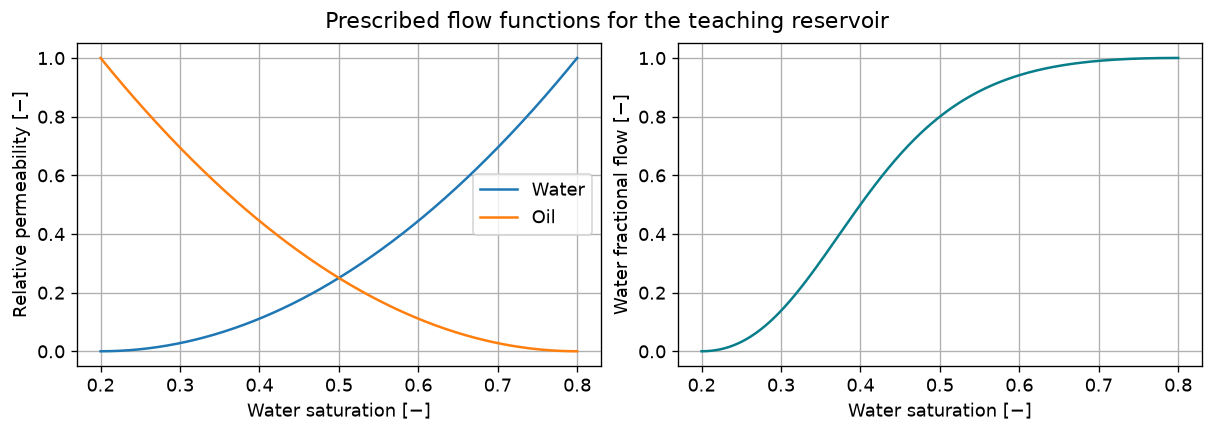

In [5]:
saturation_grid = np.linspace(0.2, 0.8, 501)
effective_grid = effective_water_saturation(saturation_grid)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), layout="constrained")
axes[0].plot(saturation_grid, effective_grid**2, label="Water")
axes[0].plot(saturation_grid, (1.0 - effective_grid) ** 2, label="Oil")
axes[0].set(xlabel="Water saturation [−]", ylabel="Relative permeability [−]")
axes[0].legend()
axes[1].plot(saturation_grid, fractional_flow(saturation_grid), color="#087e8b")
axes[1].set(xlabel="Water saturation [−]", ylabel="Water fractional flow [−]")
fig.suptitle("Prescribed flow functions for the teaching reservoir")
plt.show()

Water carries an increasing fraction of the total flow as its mobility rises. Water cut
therefore does not equal saturation. These curves determine the ideal displacement front;
changing permeability at fixed imposed rate primarily changes required pressure, while
changing the viscosity ratio changes displacement behavior.

## 5. Supply a property container

The `evaluate(state)` method fills the arrays consumed by DARTS operators: phase composition,
mass and molar density, viscosity, saturation, and relative permeability. All components and
phases use the same order: water first and oil second. We set pure-phase compositions directly
instead of calling a flash, because immiscibility is a defined assumption of this example.

`Compositional` names the engine interface used here; a compositional EOS flash is **not**
being performed inside the reservoir. For a real fluid, replace this property model with
verified flash/property evaluators and qualify their state range before running the grid.

In [6]:
class ImmiscibleProperties(PropertyContainer):
    """Two pure liquid phases with prescribed, pressure-independent properties."""

    def __init__(self):
        super().__init__(
            phases_name=["water", "oil"],
            components_name=["H2O", "C10"],
            Mw=molecular_weight_kg_kmol,
            eps_z=epsilon,
            rock_comp=0.0,
            temperature=case["temperature_K"],
        )

    def evaluate(self, state):
        self.clean_arrays()
        self.pressure = state[0]
        self.ph = np.array([0, 1], dtype=np.intp)
        self.x[:] = np.eye(2)
        self.x_mass[:] = np.eye(2)
        self.dens[:] = density_kg_m3
        self.dens_m[:] = molar_density_kmol_m3
        self.mu[:] = viscosity_cp
        self.nu[:] = [state[1], 1.0 - state[1]]
        self.compute_saturation(self.ph)
        effective = effective_water_saturation(self.sat[0])
        self.kr[:] = [effective**2, (1.0 - effective) ** 2]


properties_demo = ImmiscibleProperties()
properties_demo.evaluate([210.0, mole_fraction_from_saturation(0.35)])
display(
    pd.DataFrame(
        {
            "Phase": properties_demo.phases_name,
            "Saturation [−]": properties_demo.sat,
            "Molar density [kmol/m³]": properties_demo.dens_m,
            "Viscosity [cP]": properties_demo.mu,
            "Relative permeability [−]": properties_demo.kr,
        }
    )
)
assert np.isclose(properties_demo.sat.sum(), 1.0)
assert np.isclose(properties_demo.sat[0], 0.35)

,Phase,Saturation [−],Molar density [kmol/m³],Viscosity [cP],Relative permeability [−]
0,water,0.35,55.509298,0.5,0.0625
1,oil,0.65,5.130548,2.0,0.5625


## 6. Build the reservoir model and well controls

The grid is 300 × 20 × 5 m, divided into 60 cells along its length. One injector connects
to the first cell; one producer connects to the last. `res_cell_idx=(i, j, k)` uses
**one-based** structured-grid indices for perforations. Field arrays later use normal
zero-based NumPy indexing, with the x-index varying fastest.

The injector requests 20 actual m³/day of water, subject to a 450 bara BHP limit. The producer
holds 200 bara BHP. DARTS calculates well indices from geometry and permeability. The
450 bara value is a teaching control, not a fracture-pressure assessment.

`n_points` controls OBL points **per primary-variable axis**; `nx` controls spatial resolution;
`max_ts` controls the largest implicit time step in days. Changing one does not refine the
others. Pure-water injection includes a trace oil fraction of $10^{-10}$ to avoid a singular
composition endpoint. The interpolation domain includes the physical endpoints and spans
100–500 bara. The notebook checks that the solution remains within this pressure domain.

Subclass methods below correspond to the usual upstream `model.py`; the run cells play
the role of `main.py`. Keeping them in the notebook makes every modeling choice visible.

In [7]:
class WaterfloodModel(DartsModel):
    def __init__(
        self,
        nx=60,
        n_points=301,
        max_ts=1.0,
        injection_rate=20.0,
        permeability=300.0,
        injector_limit=450.0,
        start_with_bhp=False,
    ):
        super().__init__()
        self.nx = nx
        self.injection_rate = injection_rate
        self.injector_limit = injector_limit
        self.start_with_bhp = start_with_bhp
        self.reservoir = StructReservoir(
            self.timer,
            nx=nx,
            ny=1,
            nz=1,
            dx=case["length_m"] / nx,
            dy=case["width_m"],
            dz=case["thickness_m"],
            permx=permeability,
            permy=permeability,
            permz=permeability / 10.0,
            poro=case["porosity"],
            depth=1500.0,
        )
        self.properties = ImmiscibleProperties()
        self.physics = Compositional(
            components=["H2O", "C10"],
            phases=["water", "oil"],
            timer=self.timer,
            n_points=n_points,
            min_p=100.0,
            max_p=500.0,
            min_z=0.0,
            max_z=1.0,
            epsilon_z=epsilon,
            state_spec=Compositional.StateSpecification.P,
            extrapolation_flag=False,
        )
        self.physics.add_property_region(self.properties)
        self.set_sim_params(
            first_ts=0.01,
            mult_ts=2.0,
            max_ts=max_ts,
            tol_newton=1e-8,
            tol_linear=1e-10,
            it_newton=20,
        )
        self.data_ts.linear_type = sim_params.linear_solver_t.cpu_superlu

    def set_wells(self):
        self.reservoir.add_well("INJ")
        self.reservoir.add_perforation("INJ", res_cell_idx=(1, 1, 1))
        self.reservoir.add_well("PROD")
        self.reservoir.add_perforation("PROD", res_cell_idx=(self.nx, 1, 1))

    def set_initial_conditions(self):
        self.physics.set_initial_conditions_from_array(
            self.reservoir.mesh,
            {
                self.physics.vars[0]: case["initial_pressure_bara"],
                self.physics.vars[1]: mole_fraction_from_saturation(0.2),
            },
        )

    def set_well_controls(self):
        injector, producer = self.reservoir.wells
        rate_control = injector.constraint if self.start_with_bhp else injector.control
        pressure_control = (
            injector.control if self.start_with_bhp else injector.constraint
        )
        self.physics.set_well_controls(
            wctrl=rate_control,
            control_type=well_control_iface.VOLUMETRIC_RATE,
            is_inj=True,
            target=self.injection_rate,
            phase_name="water",
            inj_composition=[1.0 - epsilon],
        )
        self.physics.set_well_controls(
            wctrl=pressure_control,
            control_type=well_control_iface.BHP,
            is_inj=True,
            target=self.injector_limit,
            inj_composition=[1.0 - epsilon],
        )
        self.physics.set_well_controls(
            wctrl=producer.control,
            control_type=well_control_iface.BHP,
            is_inj=False,
            target=case["producer_bhp_bara"],
        )


print("Model and property classes defined; no simulation has run yet.")

Model and property classes defined; no simulation has run yet.


## 7. Initialize, advance time, and retain output

Call `init()` before `set_output()`, then `run(days)`. The `days` argument is an **increment**:
calling `run(75)` and then `run(165)` advances to day 240. It does not reset the simulation.
Each case below has its own output directory so sensitivity runs cannot overwrite each other.

DARTS stores reservoir and well states in HDF5. `store_well_time_data()` evaluates well
properties and returns a dictionary suitable for a DataFrame. We retain pressure and
saturation profiles at 75, 120, and 240 days, plus the full accepted-step well history.
The engine state also contains well blocks; exclude them when plotting the reservoir grid.

In [8]:
import contextlib
import html
import io

validation_checks = []


def require(name, condition, detail):
    passed = bool(condition)
    validation_checks.append({"Check": name, "Passed": passed, "Evidence": detail})
    assert passed, f"{name}: {detail}"


def solver_log_excerpt(log_text):
    lines = log_text.splitlines()
    alerts = [line for line in lines if "warning" in line.lower() or "FAILED" in line]
    corrections = sum("Composition correction applied" in line for line in lines)
    return "\n".join(
        [
            *lines[:12],
            f"... {len(lines)} log lines retained in the case directory ...",
            f"Native composition-bound correction messages: {corrections}",
            *alerts,
            "Final step:",
            *lines[-10:],
        ]
    )


def reservoir_snapshot(model):
    state = np.asarray(model.physics.engine.X).reshape(-1, model.physics.n_vars)
    reservoir_state = state[: model.reservoir.mesh.n_res_blocks].copy()
    return {
        "time_day": float(model.physics.engine.t),
        "pressure_bara": reservoir_state[:, 0],
        "water_saturation": saturation_from_mole_fraction(reservoir_state[:, 1]),
    }


def run_case(name, **model_options):
    folder = output_root / name
    folder.mkdir()
    native_log = folder / "darts.log"
    redirect_darts_output(str(native_log))
    python_log = io.StringIO()
    started = time.perf_counter()
    snapshots = {}
    with contextlib.redirect_stdout(python_log):
        model = WaterfloodModel(**model_options)
        model.init()
        model.set_output(output_folder=str(folder))
        snapshots[0.0] = reservoir_snapshot(model)
        for target_day in [75.0, 120.0, 240.0]:
            model.run(target_day - float(model.physics.engine.t), verbose=False)
            snapshots[target_day] = reservoir_snapshot(model)
        time_data = pd.DataFrame(
            model.output.store_well_time_data(save_output_files=False)
        )
    log_text = python_log.getvalue() + native_log.read_text()
    (folder / "complete_log.txt").write_text(log_text)
    statistics = model.physics.engine.stat
    summary = {
        "Case": name,
        "Cells": model.nx,
        "Accepted steps": int(statistics.n_timesteps_total),
        "Rejected steps": int(statistics.n_timesteps_wasted),
        "Newton iterations": int(statistics.n_newton_total),
        "Wall time [s]": time.perf_counter() - started,
    }
    return {
        "name": name,
        "model": model,
        "snapshots": snapshots,
        "rates": time_data,
        "statistics": summary,
        "log": log_text,
        "folder": folder,
    }


base = run_case("base")
display(pd.DataFrame([base["statistics"]]))
display(
    HTML(
        "<details><summary>Setup and final-step convergence; full log in case folder</summary><pre>"
        + html.escape(solver_log_excerpt(base["log"]))
        + "</pre></details>"
    )
)
require(
    "Requested end time", np.isclose(base["model"].physics.engine.t, 240.0), "240 days"
)
require(
    "No interpolation warning", "warning" not in base["log"].lower(), "Stored DARTS log"
)

,Case,Cells,Accepted steps,Rejected steps,Newton iterations,Wall time [s]
0,base,60,246,0,704,0.399643


## 8. Read signed rates, pressure, and saturation

In the pinned output API, **positive rates enter the reservoir and negative rates leave it**.
For production plots, explicitly negate the producer rates. Do not apply an unconditional
absolute value; it would hide a reversed well. The named `by_sum_perfs` rates cross the
reservoir boundary and are used for reservoir conservation. `at_wh` rates cross the
modeled wellhead boundary; small differences can arise from the storage in well segments.

These are actual-volume rates. Their labels must not be reused as standard-volume rates
or as the black-oil stock-tank vectors used in the OPM notebooks.

,Time [day],Injector BHP [bara],Producer BHP [bara],Water injection [m³/day],Signed water production [m³/day],Signed oil production [m³/day]
0,0.01,248.406780,200.0,20.0,-0.000039,-19.999961
80,75.00,238.703255,200.0,20.0,-0.000039,-19.999961
125,120.00,231.139250,200.0,20.0,-13.944122,-6.055878
245,240.00,223.422740,200.0,20.0,-17.918471,-2.081529


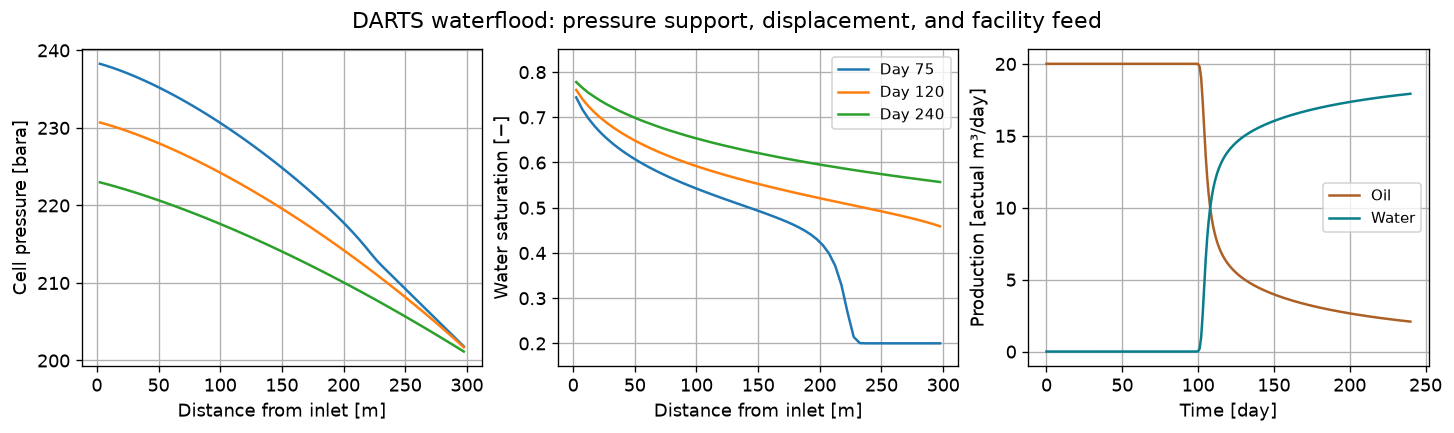

At day 240, oil production is **2.082 actual m³/day** and water production is **17.918 actual m³/day** (water cut **89.6%**).

In [9]:
rates = base["rates"]
columns = {
    "time": "Time [day]",
    "well_INJ_BHP": "Injector BHP [bara]",
    "well_PROD_BHP": "Producer BHP [bara]",
    "well_INJ_volumetric_rate_water_by_sum_perfs": "Water injection [m³/day]",
    "well_PROD_volumetric_rate_water_by_sum_perfs": "Signed water production [m³/day]",
    "well_PROD_volumetric_rate_oil_by_sum_perfs": "Signed oil production [m³/day]",
}
require(
    "Expected rate columns", set(columns).issubset(rates.columns), "Pinned output API"
)
selected_rows = sorted(
    {0, *(int(np.argmin(abs(rates.time - day))) for day in [75, 120, 240])}
)
display(rates.iloc[selected_rows][list(columns)].rename(columns=columns))
oil_rate = -rates["well_PROD_volumetric_rate_oil_by_sum_perfs"].to_numpy()
water_rate = -rates["well_PROD_volumetric_rate_water_by_sum_perfs"].to_numpy()
water_cut = water_rate / (water_rate + oil_rate)
require(
    "Production sign",
    (oil_rate >= 0).all() and (water_rate >= 0).all(),
    "Producer outflow",
)
require("Water-cut bounds", ((water_cut >= 0) & (water_cut <= 1)).all(), "Fraction 0–1")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), layout="constrained")
positions_m = (np.arange(base["model"].nx) + 0.5) * case["length_m"] / base["model"].nx
for day in [75.0, 120.0, 240.0]:
    snapshot = base["snapshots"][day]
    axes[0].plot(positions_m, snapshot["pressure_bara"], label=f"Day {day:g}")
    axes[1].plot(positions_m, snapshot["water_saturation"], label=f"Day {day:g}")
axes[0].set(xlabel="Distance from inlet [m]", ylabel="Cell pressure [bara]")
axes[1].set(
    xlabel="Distance from inlet [m]", ylabel="Water saturation [−]", ylim=(0.15, 0.85)
)
axes[1].legend(fontsize=9)
axes[2].plot(rates.time, oil_rate, label="Oil", color="#ac6026")
axes[2].plot(rates.time, water_rate, label="Water", color="#087e8b")
axes[2].set(xlabel="Time [day]", ylabel="Production [actual m³/day]")
axes[2].legend(fontsize=9)
fig.suptitle("DARTS waterflood: pressure support, displacement, and facility feed")
plt.show()
display(
    Markdown(
        f"At day 240, oil production is **{oil_rate[-1]:.3f} actual m³/day** and "
        f"water production is **{water_rate[-1]:.3f} actual m³/day** "
        f"(water cut **{water_cut[-1]:.1%}**)."
    )
)

The pressure gradient supplies viscous flow to the fixed-BHP producer. Cell pressure at the
producer is above the specified well BHP because flow crosses a finite well connection.
The water front advances and spreads numerically; after arrival, the produced water fraction
increases while oil rate declines. In a downstream study, these changing component rates
drive water-handling and cooling loads even when total reservoir-volume production is steady.

## 9. Component material balance

Audit the **reservoir cells only**, using fluxes summed over well perforations:

$$\Delta m_c=\sum_k\left(q_{c,\mathrm{inj},k}+q_{c,\mathrm{prod},k}\right)\Delta t_k$$

Here $q_c$ is a signed component mass rate in kg/day and $\Delta t_k$ is an accepted step
in days. Use the rate at the end of each implicit step for accumulation. A trapezoidal
integral would introduce a separate quadrature approximation to the implicit solution.

Reconstruct cell inventory from pore volume, saturation, and the prescribed phase densities.
Because the audit evaluates physical properties directly, whereas the solver interpolates
operators, a small reconstruction discrepancy is expected. This is an external inventory
audit, not a claim that we read the engine's internal discrete conservation residual.
The acceptance limit is 0.1% of the larger initial or cumulatively transferred component mass.

In [10]:
step_days = np.diff(np.r_[0.0, rates.time.to_numpy()])
cell_pore_volumes = (
    np.asarray(base["model"].reservoir.mesh.volume)[: base["model"].nx]
    * np.asarray(base["model"].reservoir.mesh.poro)[: base["model"].nx]
)
require(
    "Grid pore volume", np.isclose(cell_pore_volumes.sum(), pore_volume_m3), "6000 m³"
)
initial_sw = base["snapshots"][0.0]["water_saturation"]
final_sw = base["snapshots"][240.0]["water_saturation"]
balance_rows = []
for index, component in enumerate(["H2O", "C10"]):
    initial_saturation = initial_sw if index == 0 else 1.0 - initial_sw
    final_saturation = final_sw if index == 0 else 1.0 - final_sw
    initial_mass = np.sum(cell_pore_volumes * initial_saturation * density_kg_m3[index])
    final_mass = np.sum(cell_pore_volumes * final_saturation * density_kg_m3[index])
    injection = rates[f"well_INJ_mass_rate_{component}_by_sum_perfs"].to_numpy()
    production = rates[f"well_PROD_mass_rate_{component}_by_sum_perfs"].to_numpy()
    cumulative_in = np.dot(injection, step_days)
    cumulative_out = -np.dot(production, step_days)
    residual = final_mass - initial_mass - cumulative_in + cumulative_out
    relative_residual = abs(residual) / max(initial_mass, cumulative_in, cumulative_out)
    balance_rows.append(
        {
            "Component": component,
            "Initial [kg]": initial_mass,
            "Final [kg]": final_mass,
            "Injected [kg]": cumulative_in,
            "Produced [kg]": cumulative_out,
            "Residual [kg]": residual,
            "Relative error [%]": 100.0 * relative_residual,
        }
    )
    require(
        f"{component} inventory audit",
        relative_residual < 1e-3,
        f"{relative_residual:.3e}",
    )
balance_table = pd.DataFrame(balance_rows)
display(balance_table)
require(
    "Finite field state",
    np.isfinite(final_sw).all(),
    "Final reservoir water saturation",
)
require(
    "Saturation bounds",
    ((final_sw >= 0.2 - 1e-6) & (final_sw <= 0.8 + 1e-6)).all(),
    "0.2–0.8",
)
for day, snapshot in base["snapshots"].items():
    pressure = snapshot["pressure_bara"]
    require(
        f"Pressure within OBL at day {day:g}",
        ((pressure > 100) & (pressure < 500)).all(),
        "100–500 bara",
    )

,Component,Initial [kg],Final [kg],Injected [kg],Produced [kg],Residual [kg],Relative error [%]
0,H2O,1200000.0,3.802740e+06,4800000.0,2.196906e+06,-353.717983,0.007369
1,C10,3504000.0,1.604000e+06,0.0,1.900258e+06,258.216864,0.007369


## 10. Independent Buckley–Leverett check

For incompressible, one-dimensional, horizontal displacement without capillary pressure,
the shock connects the initial water saturation to a higher water saturation. Its tangent
condition is

$$f'_w(S_{wf})=\frac{f_w(S_{wf})-f_w(S_{wi})}{S_{wf}-S_{wi}}$$

With the quadratic flow functions above, the effective shock saturation is
$S_{ef}=1/\sqrt{1+\mu_o/\mu_w}$. The front speed and ideal breakthrough follow from

$$\frac{x_f}{L}=\frac{Qt}{PV}f'_w(S_{wf}),\qquad t_{bt}=\frac{PV}{Qf'_w(S_{wf})}$$

$Q$ is constant injected volume per day, $PV$ is pore volume in m³, $L$ is reservoir length
in m, $t$ is time in days, and $S_{wf}$ is shock saturation. Behind the shock, solve
$x/L=(Qt/PV)f'_w(S_w)$ for the continuous saturation profile. This analytical calculation
uses SciPy root finding, independently of the DARTS solver.

The original formulation is [Buckley and Leverett, 1942](https://doi.org/10.2118/942107-G).
End-cell well geometry and numerical diffusion mean a finite-grid breakthrough metric
will differ from the ideal boundary-driven shock. We explicitly define the numerical
metric as the first crossing of **50% water cut**.

In [11]:
viscosity_ratio = viscosity_cp[1] / viscosity_cp[0]
mobile_saturation_interval = 0.6
shock_saturation = 0.2 + mobile_saturation_interval / np.sqrt(1.0 + viscosity_ratio)


def fractional_flow_derivative(water_saturation):
    effective = effective_water_saturation(water_saturation)
    denominator = viscosity_ratio * effective**2 + (1.0 - effective) ** 2
    return (
        2.0
        * viscosity_ratio
        * effective
        * (1.0 - effective)
        / denominator**2
        / mobile_saturation_interval
    )


shock_slope = float(fractional_flow_derivative(shock_saturation))
analytical_breakthrough_day = (
    pore_volume_m3 / case["injection_rate_m3_day"] / shock_slope
)


def analytical_saturation(distance_m, time_day):
    pore_volumes_injected = case["injection_rate_m3_day"] * time_day / pore_volume_m3
    dimensionless_speed = (
        np.asarray(distance_m) / case["length_m"] / pore_volumes_injected
    )
    solution = []
    for speed in dimensionless_speed:
        if speed >= shock_slope:
            solution.append(0.2)
        else:
            solution.append(
                brentq(
                    lambda saturation: fractional_flow_derivative(saturation) - speed,
                    shock_saturation,
                    0.8,
                )
            )
    return np.asarray(solution)


def breakthrough_50_percent(frame):
    water = -frame["well_PROD_volumetric_rate_water_by_sum_perfs"].to_numpy()
    oil = -frame["well_PROD_volumetric_rate_oil_by_sum_perfs"].to_numpy()
    fraction = water / (water + oil)
    crossings = np.flatnonzero(fraction >= 0.5)
    if len(crossings) == 0 or crossings[0] == 0:
        raise ValueError("Need a bracketed first 50% water-cut crossing.")
    index = crossings[0]
    return float(
        np.interp(
            0.5, fraction[index - 1 : index + 1], frame.time.iloc[index - 1 : index + 1]
        )
    )


numerical_breakthrough_day = breakthrough_50_percent(rates)
relative_breakthrough_error = abs(
    numerical_breakthrough_day / analytical_breakthrough_day - 1.0
)
require(
    "Breakthrough comparison",
    relative_breakthrough_error < 0.1,
    "Less than 10% difference",
)
display(
    pd.DataFrame(
        {
            "Metric": [
                "Shock water saturation",
                "Shock water fractional flow",
                "Ideal breakthrough [day]",
                "DARTS 50% cut [day]",
            ],
            "Value": [
                shock_saturation,
                fractional_flow(shock_saturation),
                analytical_breakthrough_day,
                numerical_breakthrough_day,
            ],
        }
    )
)

,Metric,Value
0,Shock water saturation,0.468328
1,Shock water fractional flow,0.723607
2,Ideal breakthrough [day],111.246118
3,DARTS 50% cut [day],107.977658


## 11. Separate spatial, time-step, and OBL sensitivity

Run three refinements, changing one numerical control at a time. Compare the mean absolute
saturation-profile error at day 75, before breakthrough, and cumulative oil at day 240.
Wall times below describe this small notebook run only; they are not a field-scale
performance benchmark. A single refinement is evidence of sensitivity, not proof of
asymptotic convergence or calibrated field accuracy.

In [12]:
refinements = {
    "120 cells": run_case("spatial_refinement", nx=120),
    "0.5 day maximum step": run_case("time_refinement", max_ts=0.5),
    "601 OBL points per axis": run_case("obl_refinement", n_points=601),
}
numerical_cases = {"Base: 60 cells / 1 day / 301 points": base, **refinements}
resolution_rows = []
for label, result in numerical_cases.items():
    number_cells = result["model"].nx
    distance = (np.arange(number_cells) + 0.5) * case["length_m"] / number_cells
    reference_sw = analytical_saturation(distance, 75.0)
    calculated_sw = result["snapshots"][75.0]["water_saturation"]
    history = result["rates"]
    oil_history = -history["well_PROD_volumetric_rate_oil_by_sum_perfs"].to_numpy()
    time_increments = np.diff(np.r_[0.0, history.time.to_numpy()])
    resolution_rows.append(
        {
            "Case": label,
            "Mean |ΔSw| [−]": np.mean(abs(calculated_sw - reference_sw)),
            "50% water cut [day]": breakthrough_50_percent(history),
            "Oil produced [m³]": np.dot(oil_history, time_increments),
            "Accepted steps": result["statistics"]["Accepted steps"],
            "Wall time [s]": result["statistics"]["Wall time [s]"],
        }
    )
    require(
        f"{label}: no warning",
        "warning" not in result["log"].lower(),
        "Stored solver log",
    )
resolution_table = pd.DataFrame(resolution_rows).set_index("Case")
display(resolution_table)
require(
    "Spatial refinement improves profile",
    resolution_table.iloc[1]["Mean |ΔSw| [−]"]
    < resolution_table.iloc[0]["Mean |ΔSw| [−]"],
    "120-cell error below 60-cell error",
)
base_oil_volume = resolution_table.iloc[0]["Oil produced [m³]"]
for label in ["0.5 day maximum step", "601 OBL points per axis"]:
    relative_change = abs(
        resolution_table.loc[label, "Oil produced [m³]"] / base_oil_volume - 1.0
    )
    require(
        f"{label}: oil-volume sensitivity",
        relative_change < 0.02,
        f"{relative_change:.3%}",
    )

,Mean |ΔSw| [−],50% water cut [day],Oil produced [m³],Accepted steps,Wall time [s]
Case,,,,,
Base: 60 cells / 1 day / 301 points,0.024598,107.977658,2603.093636,246,0.399643
120 cells,0.017279,108.875743,2615.962940,246,0.468643
0.5 day maximum step,0.021871,108.045843,2606.414141,485,0.519583
601 OBL points per axis,0.024570,107.979063,2603.010822,246,0.772993


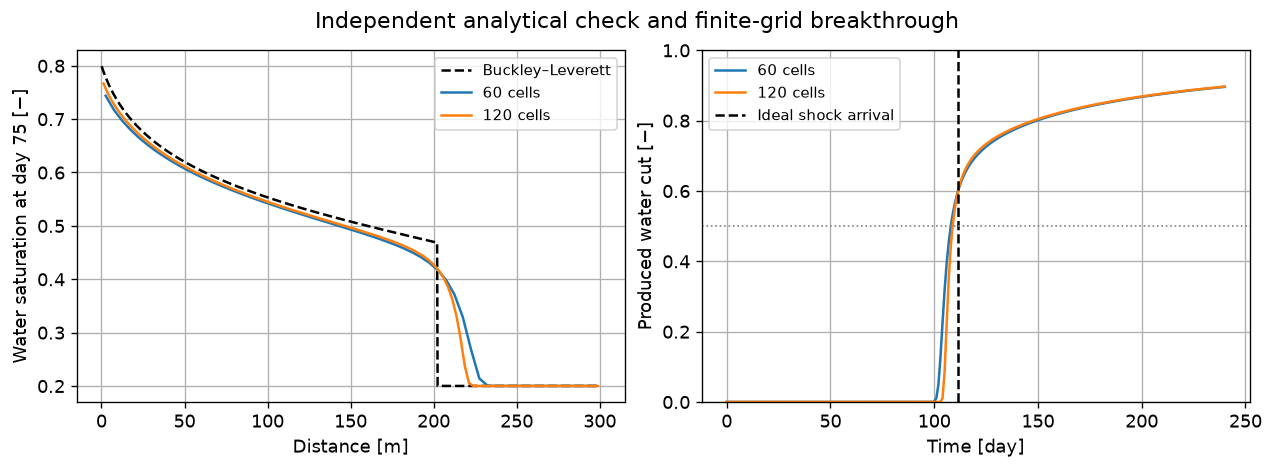

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), layout="constrained")
fine_distance = np.linspace(0.1, 299.9, 1000)
axes[0].plot(
    fine_distance,
    analytical_saturation(fine_distance, 75.0),
    color="black",
    linestyle="--",
    label="Buckley–Leverett",
)
for label, result in [("60 cells", base), ("120 cells", refinements["120 cells"])]:
    number_cells = result["model"].nx
    distance = (np.arange(number_cells) + 0.5) * 300.0 / number_cells
    axes[0].plot(distance, result["snapshots"][75.0]["water_saturation"], label=label)
    history = result["rates"]
    oil = -history["well_PROD_volumetric_rate_oil_by_sum_perfs"]
    water = -history["well_PROD_volumetric_rate_water_by_sum_perfs"]
    axes[1].plot(history.time, water / (oil + water), label=label)
axes[0].set(xlabel="Distance [m]", ylabel="Water saturation at day 75 [−]")
axes[1].axvline(
    analytical_breakthrough_day,
    color="black",
    linestyle="--",
    label="Ideal shock arrival",
)
axes[1].axhline(0.5, color="gray", linestyle=":", linewidth=1)
axes[1].set(xlabel="Time [day]", ylabel="Produced water cut [−]", ylim=(0, 1))
for axis in axes:
    axis.legend(fontsize=9)
fig.suptitle("Independent analytical check and finite-grid breakthrough")
plt.show()

The refined spatial grid gives a sharper front and a smaller profile error. The numerical
water-cut curve rises continuously through 50%, while the ideal solution has a shock.
Use the table to distinguish spatial dispersion from time-discretization and OBL effects.
For engineering forecasts, repeat such checks on the quantities that determine a decision,
including component inventories and facility loading, and validate the fluid and rock models.

## 12. Change a control during a run

Build a separate model, run to day 120, change the injector's water-rate target from
20 to 10 m³/day, and continue for another 120 days. This demonstrates **continuation in the
same engine state**, without reinitializing the reservoir. A file-based restart is a
different workflow: use the version-specific `load_restart_data()` API and preserve grid,
physics, controls, and the original output identity.

In [14]:
schedule_folder = output_root / "rate_schedule"
schedule_folder.mkdir()
redirect_darts_output(str(schedule_folder / "darts.log"))
schedule_log = io.StringIO()
with contextlib.redirect_stdout(schedule_log):
    scheduled_model = WaterfloodModel()
    scheduled_model.init()
    scheduled_model.set_output(output_folder=str(schedule_folder))
    scheduled_model.run(120.0, verbose=False)
    state_before_change = np.array(scheduled_model.physics.engine.X, copy=True)
    scheduled_model.physics.set_well_controls(
        wctrl=scheduled_model.reservoir.wells[0].control,
        control_type=well_control_iface.VOLUMETRIC_RATE,
        is_inj=True,
        target=10.0,
        phase_name="water",
        inj_composition=[1.0 - epsilon],
    )
    require(
        "Control change preserves state",
        np.array_equal(
            state_before_change, np.asarray(scheduled_model.physics.engine.X)
        ),
        "No reinitialization",
    )
    scheduled_model.run(120.0, restart_dt=0.01, verbose=False)
    schedule_rates = pd.DataFrame(
        scheduled_model.output.store_well_time_data(save_output_files=False)
    )
require(
    "Continuation reaches day 240",
    np.isclose(scheduled_model.physics.engine.t, 240.0),
    "120 + 120 days",
)
require(
    "Changed injection target achieved",
    np.isclose(
        schedule_rates["well_INJ_volumetric_rate_water_by_sum_perfs"].iloc[-1],
        10.0,
        rtol=1e-4,
    ),
    "10 actual m³/day",
)
display(
    schedule_rates.iloc[[0, -1]][
        [
            "time",
            "well_INJ_BHP",
            "well_INJ_volumetric_rate_water_by_sum_perfs",
            "well_PROD_volumetric_rate_oil_by_sum_perfs",
        ]
    ]
)

,time,well_INJ_BHP,well_INJ_volumetric_rate_water_by_sum_perfs,well_PROD_volumetric_rate_oil_by_sum_perfs
0,0.01,248.406780,20.0,-19.999961
251,240.00,213.022117,10.0,-1.528018


## 13. Let a pressure constraint limit the requested injection rate

In a second operating scenario, reduce permeability from 300 to 30 mD and limit injector
BHP to 230 bara, with a maximum water rate of 20 m³/day. Initialize with BHP as the active
control and rate as the constraint, so the first nonlinear solve starts from a feasible
pressure-controlled condition. This is an intentional constraint case: compare the
**achieved rate** and BHP with the requested values. A rate specified in
the input is not evidence that the reservoir can accept it. There is no fracture model here.

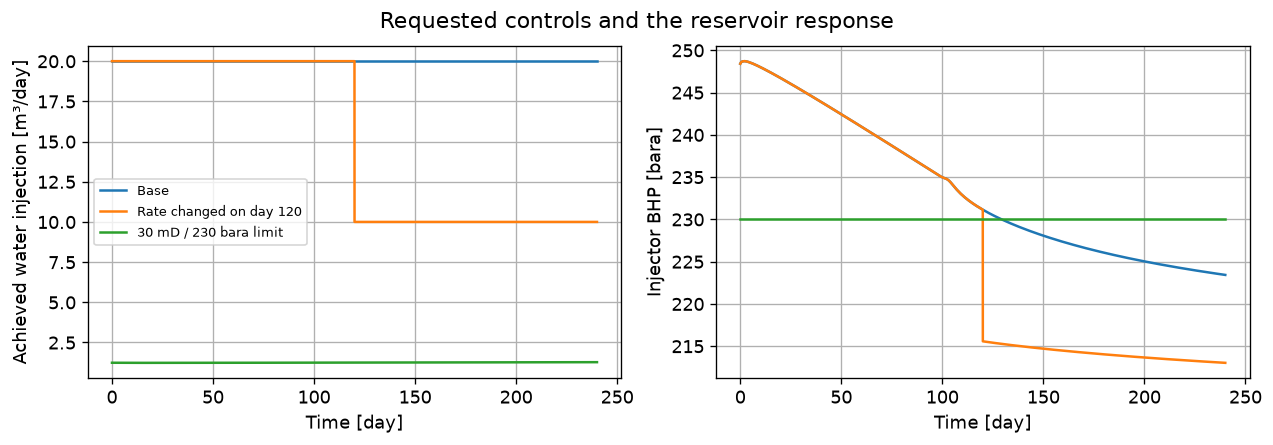

,Scenario,Final injection [m³/day],Final injector BHP [bara]
0,Base,20.00000,223.422740
1,Rate changed on day 120,10.00000,213.022117
2,30 mD / 230 bara limit,1.27543,230.000000


In [15]:
limited = run_case(
    "pressure_limited",
    permeability=30.0,
    injector_limit=230.0,
    start_with_bhp=True,
)
limited_rates = limited["rates"]
actual_limited_injection = limited_rates["well_INJ_volumetric_rate_water_by_sum_perfs"]
require(
    "Injector pressure limit respected",
    limited_rates.well_INJ_BHP.max() < 230.001,
    "230 bara",
)
require(
    "Pressure limit reduces rate",
    actual_limited_injection.iloc[-1] < 20.0,
    "Requested 20 m³/day",
)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6), layout="constrained")
histories = {
    "Base": rates,
    "Rate changed on day 120": schedule_rates,
    "30 mD / 230 bara limit": limited_rates,
}
for label, history in histories.items():
    axes[0].plot(
        history.time,
        history["well_INJ_volumetric_rate_water_by_sum_perfs"],
        label=label,
    )
    axes[1].plot(history.time, history.well_INJ_BHP, label=label)
axes[0].set(xlabel="Time [day]", ylabel="Achieved water injection [m³/day]")
axes[1].set(xlabel="Time [day]", ylabel="Injector BHP [bara]")
axes[0].legend(fontsize=8)
fig.suptitle("Requested controls and the reservoir response")
plt.show()
display(
    pd.DataFrame(
        [
            {
                "Scenario": label,
                "Final injection [m³/day]": history[
                    "well_INJ_volumetric_rate_water_by_sum_perfs"
                ].iloc[-1],
                "Final injector BHP [bara]": history.well_INJ_BHP.iloc[-1],
            }
            for label, history in histories.items()
        ]
    )
)

The lower-permeability model reaches its BHP constraint and injects less than requested.
The schedule case changes the operating target without resetting the displacement history.
Pressure-constrained production optimization needs the same distinction between targets,
constraints, and calculated rates, plus a wellbore and surface-system feedback loop.

## 14. Transfer component rates to NeqSim

Carry conserved components across the simulator boundary; do not pass reservoir phase
volumes as surface phase volumes. We now use the producer's **wellhead component molar
rates**, with an explicit component map: DARTS `H2O → water` and `C10 → n-decane`.
NeqSim accepts `n-decane` as an input alias and stores its canonical name as `nC10`;
the audit resolves component indices through `getComponent(alias)` rather than matching
raw output-name strings.
Production signs are reversed and units converted once:

$$\dot n_c\,[\mathrm{mol/s}]=-q_{c,\mathrm{prod}}\,[\mathrm{kmol/day}]\frac{1000}{86400}$$

The modeled reservoir is isothermal at 60 °C. For the surface demonstration, **10 bara and
60 °C are imposed inlet conditions**. They are not calculated wellhead conditions from a
wellbore hydraulics/heat-loss model. We use the component fluxes from DARTS, but deliberately
do not copy its BHP or constant phase densities into the NeqSim surface fluid.

NeqSim uses Peng–Robinson with its classical mixing rule (`2`) and multi-phase checking to
reflash the transferred fluid. A choke reduces pressure to 5 bara, a cooler sets 30 °C,
and a three-phase separator produces named outlets. Molecular weights are consistent by
construction. The phase densities and partitioning can differ because the thermodynamic
models differ. This is a conservative **one-way interface demonstration**, not a jointly
calibrated reservoir/surface thermodynamic model. PR water/hydrocarbon partitioning here
is not validated against solubility measurements.

For a real fluid, align components, plus fractions, binary parameters, phase models, energy
references, and reference conditions, then check the pressure/temperature overlap. Add a
wellbore model and iterate pressures and rates if facilities constrain reservoir production.

In [16]:
Stream = jpype.JClass("neqsim.process.equipment.stream.Stream")
ThrottlingValve = jpype.JClass("neqsim.process.equipment.valve.ThrottlingValve")
Cooler = jpype.JClass("neqsim.process.equipment.heatexchanger.Cooler")
ThreePhaseSeparator = jpype.JClass(
    "neqsim.process.equipment.separator.ThreePhaseSeparator"
)
ProcessSystem = jpype.JClass("neqsim.process.processmodel.ProcessSystem")


def component_molar_flows(stream):
    fluid = stream.getFluid()
    composition = np.asarray(fluid.getMolarComposition(), dtype=float)
    total_molar_flow = float(fluid.getTotalNumberOfMoles())
    return {
        component: composition[int(fluid.getComponent(component).getComponentNumber())]
        * total_molar_flow
        for component in component_names
    }


def make_surface_process(row):
    component_flow_mol_s = {
        "water": -float(row["well_PROD_molar_rate_H2O_at_wh"]) * 1000.0 / 86400.0,
        "n-decane": -float(row["well_PROD_molar_rate_C10_at_wh"]) * 1000.0 / 86400.0,
    }
    assert all(flow >= 0.0 for flow in component_flow_mol_s.values())
    surface_fluid = SystemPrEos(333.15, 10.0)
    for component, flow_mol_s in component_flow_mol_s.items():
        surface_fluid.addComponent(component, flow_mol_s)
    surface_fluid.setMixingRule(2)
    surface_fluid.setMultiPhaseCheck(True)
    surface_fluid.setTotalFlowRate(sum(component_flow_mol_s.values()), "mol/sec")

    feed = Stream("DARTS production at imposed surface conditions", surface_fluid)
    choke = ThrottlingValve("Surface choke", feed)
    choke.setOutletPressure(5.0)
    cooler = Cooler("Production cooler", choke.getOutletStream())
    cooler.setOutTemperature(303.15)
    separator = ThreePhaseSeparator("Production separator", cooler.getOutletStream())
    process = ProcessSystem()
    for equipment in [feed, choke, cooler, separator]:
        process.add(equipment)
    process.run()

    outlets = {
        "gas": separator.getGasOutStream(),
        "oil": separator.getOilOutStream(),
        "water": separator.getWaterOutStream(),
    }
    outlet_flows = [component_molar_flows(stream) for stream in outlets.values()]
    component_residuals = {
        component: sum(flows.get(component, 0.0) for flows in outlet_flows) - inlet_flow
        for component, inlet_flow in component_flow_mol_s.items()
    }
    relative_component_error = max(
        abs(component_residuals[name]) / max(flow, 1e-12)
        for name, flow in component_flow_mol_s.items()
    )
    inlet_mass_kg_h = float(feed.getFlowRate("kg/hr"))
    outlet_mass_kg_h = sum(
        float(stream.getFlowRate("kg/hr")) for stream in outlets.values()
    )
    row_result = {
        "Time [day]": float(row["time"]),
        "Feed [kg/h]": inlet_mass_kg_h,
        "Oil outlet [kg/h]": float(outlets["oil"].getFlowRate("kg/hr")),
        "Water outlet [kg/h]": float(outlets["water"].getFlowRate("kg/hr")),
        "Gas outlet [kg/h]": float(outlets["gas"].getFlowRate("kg/hr")),
        "Cooling removed [kW]": -float(cooler.getDuty()) / 1000.0,
        "Mass residual [kg/h]": outlet_mass_kg_h - inlet_mass_kg_h,
        "Component error [fraction]": relative_component_error,
    }
    return {
        "process": process,
        "feed": feed,
        "choke": choke,
        "cooler": cooler,
        "separator": separator,
        "outlets": outlets,
        "component_flow_mol_s": component_flow_mol_s,
        "component_residuals_mol_s": component_residuals,
        "summary": row_result,
    }


surface_cases = {}
for report_day in [75.0, 120.0, 240.0]:
    row_index = int(np.argmin(abs(rates.time - report_day)))
    surface_cases[report_day] = make_surface_process(rates.iloc[row_index])
surface_table = pd.DataFrame(result["summary"] for result in surface_cases.values())
display(surface_table)

,Time [day],Feed [kg/h],Oil outlet [kg/h],Water outlet [kg/h],Gas outlet [kg/h],Cooling removed [kW],Mass residual [kg/h],Component error [fraction]
0,75.0,608.333775,608.333775,1.825001e-27,1.825001e-27,11.039397,0.000000e+00,1.344318e-16
1,120.0,765.202231,184.653283,5.805489e+02,4.694605e-27,25.396490,-4.989715e-10,3.102809e-12
2,240.0,809.915692,63.467994,7.464477e+02,5.862193e-27,29.325642,-4.399681e-11,7.947884e-13


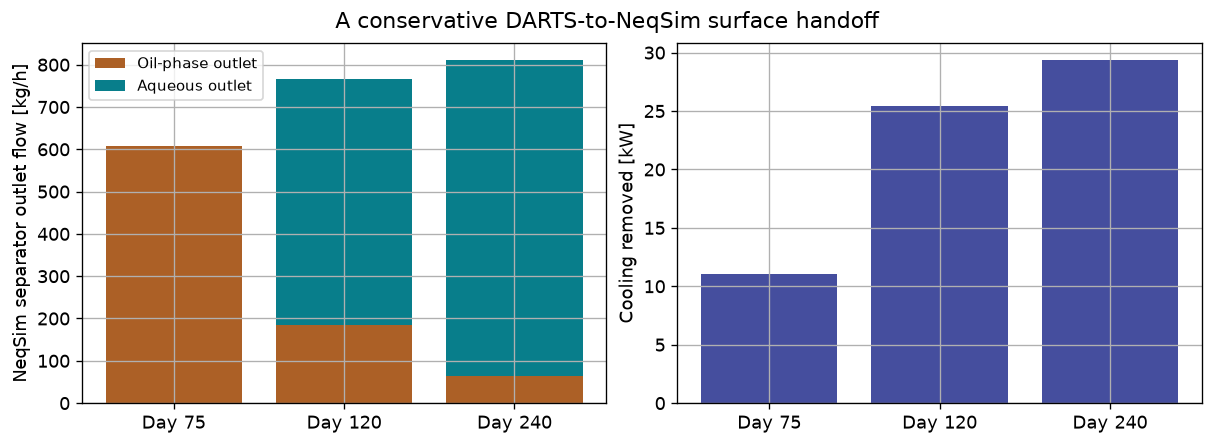

In [17]:
for report_day, result in surface_cases.items():
    summary = result["summary"]
    require(
        f"Day {report_day:g}: surface mass closure",
        abs(summary["Mass residual [kg/h]"]) / summary["Feed [kg/h]"] < 1e-8,
        f'{summary["Mass residual [kg/h]"]:.3e} kg/h',
    )
    require(
        f"Day {report_day:g}: surface component closure",
        summary["Component error [fraction]"] < 1e-7,
        f'{summary["Component error [fraction]"]:.3e}',
    )
    require(
        f"Day {report_day:g}: cooler removes heat",
        summary["Cooling removed [kW]"] > 0.0,
        f'{summary["Cooling removed [kW]"]:.3f} kW',
    )
    require(
        f"Day {report_day:g}: separator pressure",
        np.isclose(result["separator"].getOilOutStream().getPressure(), 5.0),
        "5 bara",
    )
    inlet_enthalpy = float(result["cooler"].getInletStream().getFluid().getEnthalpy())
    outlet_enthalpy = float(result["cooler"].getOutletStream().getFluid().getEnthalpy())
    energy_residual_w = (
        outlet_enthalpy - inlet_enthalpy - float(result["cooler"].getDuty())
    )
    require(
        f"Day {report_day:g}: cooler energy balance",
        abs(energy_residual_w) < 1e-5,
        f"{energy_residual_w:.3e} W",
    )

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), layout="constrained")
labels = [f"Day {int(day)}" for day in surface_table["Time [day]"]]
axes[0].bar(
    labels,
    surface_table["Oil outlet [kg/h]"],
    label="Oil-phase outlet",
    color="#ac6026",
)
axes[0].bar(
    labels,
    surface_table["Water outlet [kg/h]"],
    bottom=surface_table["Oil outlet [kg/h]"],
    label="Aqueous outlet",
    color="#087e8b",
)
axes[0].set(ylabel="NeqSim separator outlet flow [kg/h]")
axes[0].legend(fontsize=9)
axes[1].bar(labels, surface_table["Cooling removed [kW]"], color="#454e9e")
axes[1].set(ylabel="Cooling removed [kW]")
fig.suptitle("A conservative DARTS-to-NeqSim surface handoff")
plt.show()

As breakthrough increases produced water, the separator's aqueous outlet and cooling load
change. Outlet **phase** masses need not equal the incoming masses of pure chemical
components because NeqSim allows equilibrium partitioning between phases. The component
checks above enforce conservation across all gas, oil, and aqueous outlets.

There is effectively no gas production in this two-component liquid example. That is why
the chart displays liquid outlets and the table still reports the gas outlet. A live-oil
or gas-condensate extension needs a characterized multicomponent fluid before adding the
recompression train from `comparesimulations2.ipynb`.

## 15. Export a reusable handoff and retained case results

Keep both rates and their definitions. The contract below includes component mapping,
units, sign convention, time identity, imposed surface conditions, and runtime provenance.
The full time history is exported as CSV; final reservoir states are a separate CSV.
HDF5 files remain available in each case directory. The notebook also displays the key
contract fields and results, so downloading files is not required to inspect the example.

In [18]:
final_surface = surface_cases[240.0]
handoff = {
    "schema": "darts-neqsim-component-flow-v1",
    "case": "synthetic-incompressible-water-decane-waterflood",
    "time_day": 240.0,
    "source_boundary": "DARTS producer modeled wellhead component flux",
    "flow_units": "mol/s",
    "sign_convention": "positive into the surface process",
    "component_mapping": {"H2O": "water", "C10": "n-decane"},
    "component_molar_flows": final_surface["component_flow_mol_s"],
    "surface_inlet": {
        "pressure_bara": 10.0,
        "temperature_K": 333.15,
        "basis": "imposed",
    },
    "coupling": "one-way; no wellbore pressure or thermal calculation",
    "reservoir_temperature_K": case["temperature_K"],
    "darts_version": metadata.version("open-darts"),
    "darts_source_commit": "bab04c2d3f13e3b2c05798a41c2db2fe714635f8",
    "neqsim_source_ref": NEQSIM_SOURCE_REF,
    "neqsim_commit": neqsim_commit,
    "neqsim_jar_sha256": neqsim_jar_sha256,
}
(output_root / "surface_handoff.json").write_text(json.dumps(handoff, indent=2) + "\n")
rates.to_csv(output_root / "darts_well_rates.csv", index=False)
surface_table.to_csv(output_root / "neqsim_surface_results.csv", index=False)
pd.DataFrame(
    {
        "distance_m": positions_m,
        "pressure_bara": base["snapshots"][240.0]["pressure_bara"],
        "water_saturation": base["snapshots"][240.0]["water_saturation"],
    }
).to_csv(output_root / "final_reservoir_state.csv", index=False)
print(json.dumps(handoff, indent=2))
display(
    pd.DataFrame(
        [
            {"File": path.name, "Bytes": path.stat().st_size}
            for path in sorted(output_root.glob("*"))
            if path.is_file()
        ]
    )
)

{
  "schema": "darts-neqsim-component-flow-v1",
  "case": "synthetic-incompressible-water-decane-waterflood",
  "time_day": 240.0,
  "source_boundary": "DARTS producer modeled wellhead component flux",
  "flow_units": "mol/s",
  "sign_convention": "positive into the surface process",
  "component_mapping": {
    "H2O": "water",
    "C10": "n-decane"
  },
  "component_molar_flows": {
    "water": 11.512032052931627,
    "n-decane": 0.12360630813798627
  },
  "surface_inlet": {
    "pressure_bara": 10.0,
    "temperature_K": 333.15,
    "basis": "imposed"
  },
  "coupling": "one-way; no wellbore pressure or thermal calculation",
  "reservoir_temperature_K": 333.15,
  "darts_version": "1.5.0",
  "darts_source_commit": "bab04c2d3f13e3b2c05798a41c2db2fe714635f8",
  "neqsim_source_ref": "master",
  "neqsim_commit": "71835e21ef7e9c7b5a0ba809126c17b99aa864d8",
  "neqsim_jar_sha256": "6fd4ef0b4384d65c004ca9a5c1e1497a00fa752ff623b11ca0a3ce878c655ef6"
}


,File,Bytes
0,darts_well_rates.csv,245728
1,final_reservoir_state.csv,2633
2,neqsim_surface_results.csv,575
3,surface_handoff.json,957


## 16. Validation evidence and what it means

The gates below cover runtime provenance, units and signs, material inventories, finite and
bounded states, analytical comparison, numerical sensitivity, well controls, and NeqSim
mass/component/energy closure. The ideal front is the strongest independent reference here.
Conservation and sensitivity support the implementation but do not validate reservoir
properties or the PR water/oil phase partitioning against experimental measurements.

Setup and final-step native diagnostics for all additional cases are retained in the
expandable output; full iterative logs remain in the case directories. The excerpts retain
all warning and failed-step lines and count composition-bound corrections. These corrections
arise near the pure-injection endpoint; judge their effect with bounds and inventory checks.
A pressure
constraint can legitimately change a well's active control; that is a modeled outcome,
not a failed simulation. Installation logs and version-dependent numerical results should
always be reviewed when rerunning on a new environment.

In [19]:
all_case_logs = {name: result["log"] for name, result in refinements.items()}
all_case_logs["Pressure-limited case"] = limited["log"]
all_case_logs["Rate schedule"] = (
    schedule_log.getvalue() + (schedule_folder / "darts.log").read_text()
)
for name, log_text in all_case_logs.items():
    require(
        f"{name}: log has no warning",
        "warning" not in log_text.lower(),
        "Complete retained log",
    )
    display(
        HTML(
            "<details><summary>"
            + html.escape(name)
            + " — setup and final step</summary><pre>"
            + html.escape(solver_log_excerpt(log_text))
            + "</pre></details>"
        )
    )

validation_table = pd.DataFrame(validation_checks)
display(validation_table)
assert validation_table["Passed"].all()
result_summary = {
    "checks_passed": len(validation_checks),
    "checks_failed": int((~validation_table["Passed"]).sum()),
    "analytical_breakthrough_day": analytical_breakthrough_day,
    "darts_breakthrough_50_percent_day": numerical_breakthrough_day,
    "maximum_inventory_error_percent": float(balance_table["Relative error [%]"].max()),
    "oil_rate_day_240_m3_day": float(oil_rate[-1]),
    "water_rate_day_240_m3_day": float(water_rate[-1]),
    "water_cut_day_240": float(water_cut[-1]),
    "neqsim_commit": neqsim_commit,
    "neqsim_jar_sha256": neqsim_jar_sha256,
    "runtime_versions": runtime_versions,
    "python_version": platform.python_version(),
}
(output_root / "validation_summary.json").write_text(
    json.dumps(result_summary, indent=2) + "\n"
)
print(json.dumps(result_summary, indent=2))
print(f"All {len(validation_checks)} engineering checks passed.")

{
  "checks_passed": 47,
  "checks_failed": 0,
  "analytical_breakthrough_day": 111.24611797498102,
  "darts_breakthrough_50_percent_day": 107.97765830896886,
  "maximum_inventory_error_percent": 0.007369202749841404,
  "oil_rate_day_240_m3_day": 2.0815285433259443,
  "water_rate_day_240_m3_day": 17.91847145667627,
  "water_cut_day_240": 0.8959235728337143,
  "neqsim_commit": "71835e21ef7e9c7b5a0ba809126c17b99aa864d8",
  "neqsim_jar_sha256": "6fd4ef0b4384d65c004ca9a5c1e1497a00fa752ff623b11ca0a3ce878c655ef6",
  "runtime_versions": {
    "open-darts": "1.5.0",
    "open-darts-flash": "0.14.0",
    "neqsim": "3.20.0",
    "numpy": "2.5.3",
    "pandas": "3.0.5",
    "scipy": "1.18.1"
  },
  "python_version": "3.12.14"
}
All 47 engineering checks passed.


,Check,Passed,Evidence
0,Requested end time,True,240 days
1,No interpolation warning,True,Stored DARTS log
2,Expected rate columns,True,Pinned output API
3,Production sign,True,Producer outflow
4,Water-cut bounds,True,Fraction 0–1
5,Grid pore volume,True,6000 m³
6,H2O inventory audit,True,7.369e-05
7,C10 inventory audit,True,7.369e-05
8,Finite field state,True,Final reservoir water saturation
9,Saturation bounds,True,0.2–0.8


## 17. Extend the example deliberately

| Objective | DARTS change | Related NeqSim-Colab step / required check |
|---|---|---|
| Live oil or gas condensate | Replace the immiscible property container with EOS/flash evaluators and realistic components | Begin with fluid characterization and PVT; compare flash results and component definitions at shared pressure/temperature points. |
| CO2 storage | Use a suitable CO2–water/brine property model; add dissolution, density, relative permeability, and capillarity | Qualify salinity, phase states, solubility, injection conditions, and trapping; the present decane displacement is not a CO2-storage prediction. |
| Geothermal production | Add the energy equation, rock heat capacity, conductivity, and temperature-dependent properties | Verify water/steam thermodynamics and energy conservation before predicting thermal breakthrough or surface heat recovery. |
| Geological heterogeneity | Replace scalar rock properties with indexed arrays or use a supported grid representation | Start from XTGeo/RMS input QC; verify active cells, volumes, ordering, transmissibilities, wells, and upscaling. |
| History matching / uncertainty | Wrap independent model construction and runs in a forward-model worker | Follow the ERT notebooks; preserve realization IDs, observations, priors, failed-run handling, and downstream identity. |
| Integrated production optimization | Couple reservoir rates to wellbore/VLP and facility constraints, with pressure feedback | Use the well-inflow and surface-process notebooks; check rate/BHP consistency and convergence of the coupled calculation. |
| Large models or acceleration | Study operator evaluations, linear solver cost, grid size, and hardware availability | Benchmark a representative model; this small CPU example does not qualify GPU, MPI, or large-model speed. |

The new property model is usually the major engineering step. Reusing the `Compositional`
class alone does not supply validated EOS parameters, chemistry, thermal data, or rock physics.

### Troubleshooting

| Symptom | What to inspect |
|---|---|
| `ImportError` or different method signature | Installed `open-darts` version and its matching source tag; avoid mixing older `physics_sup` tutorials with this API. |
| No matching wheel | Python version and x86-64 architecture; use the official build instructions for unsupported combinations. |
| Initial-condition or well-position error | `physics.vars`, number of reservoir cells, component order, and one-based perforation indices. |
| Operator interpolation warning | Pressure/composition/temperature bounds, well controls, injection endpoints, and invalid states. Expand a domain only when the property model is valid there. |
| Repeated time-step cuts | Failed Newton iterations, phase/model validity, large control changes, sharp fronts, and tolerances; first reduce the initial/max step and inspect the log. |
| Unexpectedly low injection | Active BHP constraint, permeability, viscosity, well index, and pressure margin. |
| Material-balance discrepancy | Component mapping, rate sign, time units, molar-mass units, wellhead versus perforation boundary, integration rule, and OBL resolution. |
| Incorrect NeqSim runtime | Restart the Python runtime before changing the JVM; check the full verified JAR location and source commit. |

## 18. Exercises

1. Change oil viscosity from 2 to 5 cP. Recalculate the analytical shock and rerun all cases.
   Explain the change in breakthrough and final water cut.
2. Refine to 240 cells while keeping time and OBL resolution fixed, then refine time separately.
   Plot error versus cell width and identify whether the front is in an asymptotic regime.
3. Sweep the injector BHP limit at 30 mD. Plot achieved injection against BHP and report which
   requested rates are feasible. Do not infer a fracture limit from this experiment.
4. Construct a second property region and verify the cell-to-region map before introducing a
   permeability barrier. Explain which assumptions invalidate the homogeneous analytical check.
5. Carry the final JSON contract into a wellbore/surface workflow. Add pressure feedback and
   define a convergence criterion for a consistent operating point.
6. Replace n-decane with a characterized multicomponent oil, validate the reservoir flash, and
   connect to the separation/recompression notebook. Preserve component and energy accounting.

## 19. Sources and review boundary

Source/API inspection: **11 September 2026**. The notebook uses public synthetic inputs,
original teaching code calling the public APIs, and no downloaded field dataset.

- [open-DARTS repository](https://gitlab.com/open-darts/open-darts) and
  [pinned v1.5.0 source](https://gitlab.com/open-darts/open-darts/-/tree/bab04c2d3f13e3b2c05798a41c2db2fe714635f8).
- [Official installation and API documentation](https://open-darts.gitlab.io/open-darts/)
  and [PyPI 1.5.0 distribution metadata](https://pypi.org/project/open-darts/1.5.0/).
  The live documentation may describe APIs newer than the pinned wheel.
- [Upstream model examples](https://gitlab.com/open-darts/open-darts/-/tree/v1.5.0/models),
  including the two-phase, compositional, and thermal examples.
- [Buckley–Leverett displacement formulation](https://doi.org/10.2118/942107-G).
- [NeqSim source](https://github.com/equinor/neqsim) and
  [NeqSim-Colab catalog](../examples_of_NeqSim_in_Colab.ipynb).

Open-DARTS publishes its own [license](https://gitlab.com/open-darts/open-darts/-/blob/v1.5.0/LICENSE.md).
This notebook calls the installed library; it does not vendor its implementation. Dependency
and repository licenses remain attached to their respective projects.

**Review boundary:** this tutorial qualifies the stated synthetic cases and one-way component
interface. It does not qualify live-oil phase behavior, full reservoir/facility coupling,
field forecasts, chemistry, GPU execution, or DARTS 2.0. No NeqSim library defect was found
in the demonstrated handoff, so no new upstream bug issue is associated with this notebook.